In [ ]:
# @title
import gymnasium as gym
from gymnasium import spaces
from gymnasium.wrappers import FrameStackObservation, FlattenObservation
import numpy as np
import random
import math

# ==========================================
# KALMAN FILTERS (Identical to previous)
# ==========================================
class KalmanFilter2D_Pos:
    def __init__(self, dt, q_variance=0.01, r_variance=0.1):
        self.dt = dt
        self.x = np.zeros(4)
        self.P = np.eye(4)
        self.F = np.eye(4)
        self.F[0, 2] = dt; self.F[1, 3] = dt
        self.H = np.zeros((2, 4))
        self.H[0, 0] = 1; self.H[1, 1] = 1
        self.Q = np.eye(4) * q_variance
        self.R = np.eye(2) * r_variance

    def update(self, z):
        self.x = self.F @ self.x
        self.P = self.F @ self.P @ self.F.T + self.Q
        y = z - self.H @ self.x
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)
        self.x = self.x + K @ y
        self.P = (np.eye(4) - K @ self.H) @ self.P

class KalmanFilter1D_Angle:
    def __init__(self, dt, q_variance=0.01, r_variance=0.1):
        self.dt = dt
        self.x = np.zeros(2)
        self.P = np.eye(2)
        self.F = np.array([[1, dt], [0, 1]])
        self.H = np.array([[1, 0]])
        self.Q = np.eye(2) * q_variance
        self.R = np.array([[r_variance]])

    def update(self, z):
        self.x = self.F @ self.x
        self.P = self.F @ self.P @ self.F.T + self.Q
        y = z - (self.H @ self.x)[0]
        y = (y + math.pi) % (2 * math.pi) - math.pi
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)
        self.x = self.x + K.flatten() * y
        self.P = (np.eye(2) - K @ self.H) @ self.P
        self.x[0] = (self.x[0] + math.pi) % (2 * math.pi) - math.pi

# ==========================================
# THE NON-HOLONOMIC ENVIRONMENT
# ==========================================
class Vanguard2D(gym.Env):
    metadata = {"render_modes": ["human"], "render_fps": 30}

    def __init__(self, render_mode=None):
        super(Vanguard2D, self).__init__()

        self.target_dist = 0.8
        self.dt = 0.1

        # UPGRADED Kinematic Limits for the Cart
        self.max_lin_accel = 6.0  # Increased from 3.0
        self.max_ang_accel = 10.0 # Increased from 5.0

        self.render_mode = render_mode

        # Action: [Linear_Accel, Angular_Accel]
        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(2,), dtype=np.float32)

        # Observation (Size 8): Ego-Centric Frame
        # [Local_Err_X, Local_Err_Y, S_Vel, S_Omega, Local_P_VX, Local_P_VY, Rel_P_Theta, Est_P_Omega]
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(8,), dtype=np.float32)

        # True Physics States
        self.p_pos = np.array([0.0, 0.0], dtype=np.float32)
        self.p_vel = np.array([0.0, 0.0], dtype=np.float32)
        self.p_theta = 0.0
        self.p_omega = 0.0

        # Stroller States (Now a Unicycle Model)
        self.s_pos = np.array([0.0, 0.0], dtype=np.float32)
        self.s_vel = 0.0      # Scalar forward speed
        self.s_theta = 0.0    # Cart Heading
        self.s_omega = 0.0    # Cart Turn Rate

        self.step_count = 0

        self.kf_pos = KalmanFilter2D_Pos(self.dt)
        self.kf_angle = KalmanFilter1D_Angle(self.dt)

    def _to_ego_frame(self, global_vec, ego_theta):
        """Rotates a global vector into the Stroller's point of view."""
        c, s = math.cos(ego_theta), math.sin(ego_theta)
        # Standard rotation matrix
        x_local = global_vec[0] * c + global_vec[1] * s
        y_local = -global_vec[0] * s + global_vec[1] * c
        return np.array([x_local, y_local], dtype=np.float32)

    def _get_obs(self):
        # 1. Pull ESTIMATED state from the Kalman Filters
        est_p_pos = self.kf_pos.x[0:2]
        est_p_vel = self.kf_pos.x[2:4]
        est_theta = self.kf_angle.x[0]
        est_omega = self.kf_angle.x[1]

        # Calculate Estimated Ideal Pos
        est_dir_vec = np.array([math.cos(est_theta), math.sin(est_theta)])
        est_ideal_pos = est_p_pos + (est_dir_vec * self.target_dist)

        # 2. Ego-Centric Error Vector (Where is the ideal spot relative to my hood?)
        global_error = est_ideal_pos - self.s_pos
        local_error = self._to_ego_frame(global_error, self.s_theta)

        # 3. Person's Velocity in Ego-Frame
        local_p_vel = self._to_ego_frame(est_p_vel, self.s_theta)

        # 4. Relative Heading (Is the person facing the same way I am?)
        rel_theta = (est_theta - self.s_theta + math.pi) % (2*math.pi) - math.pi

        # Final Observation array (Size 8)
        obs = np.array([
            local_error[0], local_error[1], # X is Front/Back, Y is Left/Right
            self.s_vel, self.s_omega,
            local_p_vel[0], local_p_vel[1],
            rel_theta, est_omega
        ], dtype=np.float32)

        return obs

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.p_pos = np.array([0.0, 0.0])
        self.p_theta = random.uniform(0, 2 * math.pi)
        self.p_omega = 0.0

        init_speed = 1.2
        self.p_vel = np.array([math.cos(self.p_theta) * init_speed, math.sin(self.p_theta) * init_speed])

        # Stroller starts perfectly aligned
        dir_vec = np.array([math.cos(self.p_theta), math.sin(self.p_theta)])
        self.s_pos = self.p_pos + (dir_vec * self.target_dist)
        self.s_theta = self.p_theta
        self.s_vel = init_speed
        self.s_omega = 0.0

        # Initialize Filters
        self.kf_pos.x = np.array([self.p_pos[0], self.p_pos[1], self.p_vel[0], self.p_vel[1]])
        self.kf_angle.x = np.array([self.p_theta, self.p_omega])

        self.step_count = 0
        return self._get_obs(), {}

    def step(self, action):
        self.step_count += 1

        # --- NON-HOLONOMIC PHYSICS: Stroller ---
        # 1. Apply Accelerations
        self.s_vel += (action[0] * self.max_lin_accel) * self.dt
        self.s_omega += (action[1] * self.max_ang_accel) * self.dt

        # 2. Friction / Drag (Crucial for stability)
        self.s_vel *= 1.0
        self.s_omega *= 1.0

        # 3. UPGRADED Velocity Limits
        self.s_vel = np.clip(self.s_vel, -3.0, 6.0)  # Increased top speeds
        self.s_omega = np.clip(self.s_omega, -5.0, 5.0) # Increased max turn rates

        # 4. Update Position & Heading
        self.s_theta += self.s_omega * self.dt
        self.s_theta = (self.s_theta + math.pi) % (2*math.pi) - math.pi # Wrap angle

        self.s_pos[0] += self.s_vel * math.cos(self.s_theta) * self.dt
        self.s_pos[1] += self.s_vel * math.sin(self.s_theta) * self.dt

        # --- True Physics: Person (Medium Difficulty) ---
        omega_accel = random.uniform(-0.25, 0.25)
        self.p_omega = np.clip(self.p_omega + omega_accel, -1.3, 1.3)
        self.p_theta += self.p_omega * self.dt

        lin_accel_noise = random.uniform(-0.5, 0.5)
        current_speed = np.linalg.norm(self.p_vel)
        target_speed = np.clip(current_speed + (lin_accel_noise * self.dt), 0.5, 1.8)

        self.p_vel = np.array([math.cos(self.p_theta) * target_speed, math.sin(self.p_theta) * target_speed])
        self.p_pos += self.p_vel * self.dt

        # --- Sensor Noise & Filter Update ---
        noisy_p_pos = self.p_pos + np.random.normal(0, 0.05, size=2)
        noisy_theta = self.p_theta + np.random.normal(0, 0.08)

        self.kf_pos.update(noisy_p_pos)
        self.kf_angle.update(noisy_theta)

        # --- Reward Calculation ---
        dir_vec = np.array([math.cos(self.p_theta), math.sin(self.p_theta)])
        true_ideal_pos = self.p_pos + (dir_vec * self.target_dist)

        dist_error = np.linalg.norm(self.s_pos - true_ideal_pos)

        reward = 0.0
        reward -= 3.0 * (dist_error ** 2)
        # Penalize harsh steering/gas slightly to encourage smooth driving
        reward -= 0.05 * np.sum(action ** 2)

        # --- Termination ---
        terminated = False
        if np.linalg.norm(self.s_pos - self.p_pos) < 0.3:
            reward -= 50.0
            terminated = True
        if dist_error > 3.0:
            reward -= 100.0
            terminated = True

        truncated = (self.step_count > 500)

        return self._get_obs(), reward, terminated, truncated, {}

# --- Wrapper Helper ---
def make_vanguard_2d(render_mode=None):
    env = Vanguard2D(render_mode=render_mode)
    env = FrameStackObservation(env, stack_size=4)
    env = FlattenObservation(env)
    return env

In [ ]:
# 3/8 Iter

import gymnasium as gym
from gymnasium import spaces
from gymnasium.wrappers import FrameStackObservation, FlattenObservation
import numpy as np
import random
import math

# ==========================================
# KALMAN FILTERS
# ==========================================
class KalmanFilter2D_Pos:
    def __init__(self, dt, q_variance=0.01, r_variance=0.1):
        self.dt = dt
        self.x = np.zeros(4)
        self.P = np.eye(4)
        self.F = np.eye(4)
        self.F[0, 2] = dt; self.F[1, 3] = dt
        self.H = np.zeros((2, 4))
        self.H[0, 0] = 1; self.H[1, 1] = 1
        self.Q = np.eye(4) * q_variance
        self.R = np.eye(2) * r_variance

    def update(self, z):
        self.x = self.F @ self.x
        self.P = self.F @ self.P @ self.F.T + self.Q
        y = z - self.H @ self.x
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)
        self.x = self.x + K @ y
        self.P = (np.eye(4) - K @ self.H) @ self.P

class KalmanFilter1D_Angle:
    def __init__(self, dt, q_variance=0.01, r_variance=0.1):
        self.dt = dt
        self.x = np.zeros(2)
        self.P = np.eye(2)
        self.F = np.array([[1, dt], [0, 1]])
        self.H = np.array([[1, 0]])
        self.Q = np.eye(2) * q_variance
        self.R = np.array([[r_variance]])

    def update(self, z):
        self.x = self.F @ self.x
        self.P = self.F @ self.P @ self.F.T + self.Q
        y = z - (self.H @ self.x)[0]
        y = (y + math.pi) % (2 * math.pi) - math.pi
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)
        self.x = self.x + K.flatten() * y
        self.P = (np.eye(2) - K @ self.H) @ self.P
        self.x[0] = (self.x[0] + math.pi) % (2 * math.pi) - math.pi

# ==========================================
# THE NON-HOLONOMIC ENVIRONMENT
# ==========================================
class Vanguard2D(gym.Env):
    metadata = {"render_modes": ["human"], "render_fps": 30}

    def __init__(self, render_mode=None):
        super(Vanguard2D, self).__init__()

        self.target_dist = 0.8
        self.dt = 0.1

        self.max_lin_accel = 6.0
        self.max_ang_accel = 10.0

        self.render_mode = render_mode

        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(2,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(8,), dtype=np.float32)

        self.p_pos = np.array([0.0, 0.0], dtype=np.float32)
        self.p_vel = np.array([0.0, 0.0], dtype=np.float32)
        self.p_theta = 0.0
        self.p_omega = 0.0

        self.s_pos = np.array([0.0, 0.0], dtype=np.float32)
        self.s_vel = 0.0
        self.s_theta = 0.0
        self.s_omega = 0.0

        self.step_count = 0

        self.kf_pos = KalmanFilter2D_Pos(self.dt)
        self.kf_angle = KalmanFilter1D_Angle(self.dt)

    def _to_ego_frame(self, global_vec, ego_theta):
        c, s = math.cos(ego_theta), math.sin(ego_theta)
        x_local = global_vec[0] * c + global_vec[1] * s
        y_local = -global_vec[0] * s + global_vec[1] * c
        return np.array([x_local, y_local], dtype=np.float32)

    def _get_obs(self):
        est_p_pos = self.kf_pos.x[0:2]
        est_p_vel = self.kf_pos.x[2:4]
        est_theta = self.kf_angle.x[0]
        est_omega = self.kf_angle.x[1]

        est_dir_vec = np.array([math.cos(est_theta), math.sin(est_theta)])
        est_ideal_pos = est_p_pos + (est_dir_vec * self.target_dist)

        global_error = est_ideal_pos - self.s_pos
        local_error = self._to_ego_frame(global_error, self.s_theta)

        local_p_vel = self._to_ego_frame(est_p_vel, self.s_theta)
        rel_theta = (est_theta - self.s_theta + math.pi) % (2*math.pi) - math.pi

        obs = np.array([
            local_error[0], local_error[1],
            self.s_vel, self.s_omega,
            local_p_vel[0], local_p_vel[1],
            rel_theta, est_omega
        ], dtype=np.float32)

        return obs

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.p_pos = np.array([0.0, 0.0])
        self.p_theta = random.uniform(0, 2 * math.pi)
        self.p_omega = 0.0

        init_speed = 1.2
        self.p_vel = np.array([math.cos(self.p_theta) * init_speed, math.sin(self.p_theta) * init_speed])

        dir_vec = np.array([math.cos(self.p_theta), math.sin(self.p_theta)])
        self.s_pos = self.p_pos + (dir_vec * self.target_dist)
        self.s_theta = self.p_theta
        self.s_vel = init_speed
        self.s_omega = 0.0

        self.kf_pos.x = np.array([self.p_pos[0], self.p_pos[1], self.p_vel[0], self.p_vel[1]])
        self.kf_angle.x = np.array([self.p_theta, self.p_omega])

        self.step_count = 0
        return self._get_obs(), {}

    def step(self, action):
        self.step_count += 1

        self.s_vel += (action[0] * self.max_lin_accel) * self.dt
        self.s_omega += (action[1] * self.max_ang_accel) * self.dt

        self.s_vel *= 1.0
        self.s_omega *= 1.0

        self.s_vel = np.clip(self.s_vel, -3.0, 6.0)
        self.s_omega = np.clip(self.s_omega, -5.0, 5.0)

        self.s_theta += self.s_omega * self.dt
        self.s_theta = (self.s_theta + math.pi) % (2*math.pi) - math.pi

        self.s_pos[0] += self.s_vel * math.cos(self.s_theta) * self.dt
        self.s_pos[1] += self.s_vel * math.sin(self.s_theta) * self.dt

        omega_accel = random.uniform(-0.25, 0.25)
        self.p_omega = np.clip(self.p_omega + omega_accel, -1.3, 1.3)
        self.p_theta += self.p_omega * self.dt

        lin_accel_noise = random.uniform(-0.5, 0.5)
        current_speed = np.linalg.norm(self.p_vel)
        target_speed = np.clip(current_speed + (lin_accel_noise * self.dt), 0.5, 1.8)

        self.p_vel = np.array([math.cos(self.p_theta) * target_speed, math.sin(self.p_theta) * target_speed])
        self.p_pos += self.p_vel * self.dt

        noisy_p_pos = self.p_pos + np.random.normal(0, 0.05, size=2)
        noisy_theta = self.p_theta + np.random.normal(0, 0.08)

        self.kf_pos.update(noisy_p_pos)
        self.kf_angle.update(noisy_theta)

        dir_vec = np.array([math.cos(self.p_theta), math.sin(self.p_theta)])
        true_ideal_pos = self.p_pos + (dir_vec * self.target_dist)

        dist_error = np.linalg.norm(self.s_pos - true_ideal_pos)

        # --- UPDATED REWARD CALCULATION ---
        reward = 10.0 # Base positive reward for tracking successfully
        reward -= 3.0 * (dist_error ** 2)
        reward -= 0.05 * np.sum(action ** 2)

        terminated = False
        if np.linalg.norm(self.s_pos - self.p_pos) < 0.3:
            reward -= 50.0
            terminated = True
        if dist_error > 3.0:
            reward -= 100.0
            terminated = True

        truncated = (self.step_count > 500)

        return self._get_obs(), reward, terminated, truncated, {}

# --- Wrapper Helper ---
def make_vanguard_2d(render_mode=None):
    env = Vanguard2D(render_mode=render_mode)
    env = FrameStackObservation(env, stack_size=4)
    env = FlattenObservation(env)
    return env

In [ ]:
from stable_baselines3 import PPO
import os

# 1. Create the 2D Environment
# Note: We must use the wrapper function to get the Frame Stacking
env = make_vanguard_2d(render_mode=None)

# 2. Initialize PPO
model = PPO("MlpPolicy", env, verbose=1)

print("Starting 2D Training...")
print(f"Observation Space: {env.observation_space.shape}") # Should be (32,)

# 3. Train
# 2D is harder, so we might need more steps.
# 100k is a good start, but 300k might be better for smooth turning.
model.learn(total_timesteps=2000000)

print("Training Complete!")
model.save("vanguard_2d_ppo")

Streaming output truncated to the last 5000 lines.
|    n_updates            | 7490        |
|    policy_gradient_loss | -0.00818    |
|    std                  | 0.203       |
|    value_loss           | 1.04        |
-----------------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 496         |
|    ep_rew_mean          | 4.89e+03    |
| time/                   |             |
|    fps                  | 592         |
|    iterations           | 751         |
|    time_elapsed         | 2595        |
|    total_timesteps      | 1538048     |
| train/                  |             |
|    approx_kl            | 0.025809202 |
|    clip_fraction        | 0.292       |
|    clip_range           | 0.2         |
|    entropy_loss         | 0.357       |
|    explained_variance   | 0.149       |
|    learning_rate        | 0.0003      |
|    loss                 | 0.499       |
|    n_updates           

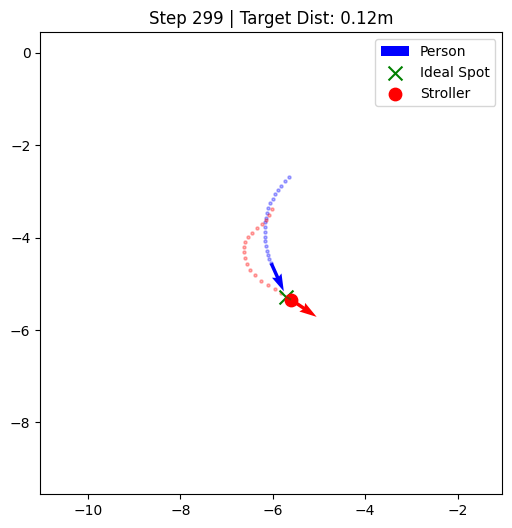

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
import numpy as np
import time
import math

# 1. Load Environment & Model
env = make_vanguard_2d(render_mode=None)
# model = PPO.load("vanguard_2d_ppo")

obs, _ = env.reset()

p_trail_x, p_trail_y = [], []
s_trail_x, s_trail_y = [], []

print("Starting Non-Holonomic 2D Simulation...")

try:
    for step in range(300):

        # The AI drives the unicycle
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)

        base_env = env.unwrapped

        px, py = base_env.p_pos
        sx, sy = base_env.s_pos
        p_theta = base_env.p_theta
        s_theta = base_env.s_theta # Grab the Stroller's heading

        p_trail_x.append(px); p_trail_y.append(py)
        s_trail_x.append(sx); s_trail_y.append(sy)
        if len(p_trail_x) > 20: p_trail_x.pop(0); p_trail_y.pop(0)
        if len(s_trail_x) > 20: s_trail_x.pop(0); s_trail_y.pop(0)

        ix = px + math.cos(p_theta) * base_env.target_dist
        iy = py + math.sin(p_theta) * base_env.target_dist

        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(6, 6))

        ax.set_xlim(px - 5, px + 5)
        ax.set_ylim(py - 5, py + 5)
        ax.set_aspect('equal')

        ax.scatter(p_trail_x, p_trail_y, c='blue', s=5, alpha=0.3)
        ax.scatter(s_trail_x, s_trail_y, c='red', s=5, alpha=0.3)

        # Draw Person (Blue Arrow)
        ax.quiver(px, py, math.cos(p_theta), math.sin(p_theta), color='blue', scale=15, label='Person')

        # Draw Ideal Spot (Green X)
        ax.scatter(ix, iy, c='green', marker='x', s=100, label='Ideal Spot')

        # Draw Stroller Dot AND Heading Arrow (Red)
        ax.scatter(sx, sy, c='red', s=80, label='Stroller')
        ax.quiver(sx, sy, math.cos(s_theta), math.sin(s_theta), color='red', scale=15)

        ax.plot([sx, ix], [sy, iy], 'g--', alpha=0.5)

        ax.legend(loc='upper right')
        ax.set_title(f"Step {step} | Target Dist: {np.linalg.norm([sx-ix, sy-iy]):.2f}m")
        plt.show()

        if terminated or truncated:
            print("Episode Reset")
            obs, _ = env.reset()
            p_trail_x, p_trail_y = [], []
            s_trail_x, s_trail_y = [], []

except KeyboardInterrupt:
    print("Stopped.")